# Can the model tell a true combination from co-occurring single signals?

For each ligand pair, notebook 01 built a synthetic `mix_AB` profile: the bulk transcriptome
of a population that is half A-stimulated and half B-stimulated cells. Both `mix_AB` and the
real A+B well (`real_combo`) contain A and B signal, but only `real_combo` contains a true
combinatorial response.

This notebook asks whether the model can tell them apart. The key readout is `z_AB`: the
model's z-score for the combinatorial activity that the ligand pair maps onto.

Sections:

1. Analysis frame: load scores and average across replicates
2. `z_AB` in real combination vs. mixture
3. Combinatorial vs. single activity effect sizes
4. Per-pair breakdown

## Setup

In [1]:
import os
import warnings

import cnsplots as cns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

warnings.filterwarnings("ignore")

# ---- inputs -----------------------------------------------------------------------------------
# Repo-relative paths (inputs: imports_stable/, outputs: analysis_outs/)
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/03_activity_inference_model"
INDIR = f"{IMPORTS_DIR}/SIG13/analysis_outs/inference_model_mixture_validation"  # 01_build_and_score_mixtures outputs
OUTDIR = f"{OUTS_DIR}/inference_model_mixture_validation"
FIGDIR = f"{OUTDIR}/figures"
os.makedirs(FIGDIR, exist_ok=True)

# ---- analysis constants -------------------------------------------------------------------
DATASETS = ["SIG26-6h", "SIG14"]
SAMPLE_TYPES = ["real_control", "mix_AB", "real_combo"]
TRIPLET_KEYS = ["dataset", "triplet"]     # the unit of analysis: one ligand pair
ROLE_ORDER = ["single A", "single B", "combinatorial"]
STIMULATED = ["mix_AB", "real_combo"]

# ---- cnsplots figure style ----------------------------------------------------------------
cns.settings.font_sans_serif = ("Nimbus Sans", "Arial", "Helvetica", "DejaVu Sans")
cns.settings.panel_label_fontname = "Nimbus Sans"
cns.setup_matplotlib()
plt.rcParams["axes.unicode_minus"] = False   # cns.savefig reassigns non-ASCII text to DejaVu Sans


def savefig(name):
    """Write the current cnsplots figure as PDF and show it inline."""
    cns.savefig(f"{FIGDIR}/{name}.pdf")
    plt.show()

## 1. Analysis frame

Activity profiles (38 activities) are averaged across replicates for each ligand pair and
sample type. All readouts are computed from these averaged profiles.

Two kinds of readout:

- **Raw:** `z_AB`, the z-score of the pair's combinatorial activity.
- **Control-subtracted:** each profile minus its own pair's `real_control` profile, giving
  `d_AB`, `d_A`, `d_B` (combinatorial, single A, single B). This is needed because z-scores
  are relative to a permutation null, not to unstimulated cells, so an activity can be
  non-zero even in control wells.

In [2]:
# columns that identify a ligand pair and are constant across its replicates
PAIR_COLS = ["dataset", "triplet", "ligand_A", "ligand_B",
             "activity_A", "activity_B", "activity_AB", "sample_type"]


def load_dataset(dataset):
    """Average each ligand pair's activity profile across replicates, then derive the
    per-pair readouts from that averaged profile."""
    scores = pd.read_csv(f"{INDIR}/activity_mixtures_{dataset}.csv")
    index = pd.read_csv(f"{INDIR}/sample_index_{dataset}.csv")
    activities = [c for c in scores.columns if c != "sample"]

    merged = index.merge(scores, left_on="sample_id", right_on="sample", how="left")
    # dropna=False keeps the IL1B pairs, whose activity_B is null
    frame = (merged.groupby(PAIR_COLS, dropna=False, as_index=False)
                   .agg(n_replicates=("replicate", "nunique"),
                        **{activity: (activity, "mean") for activity in activities}))

    matrix = frame[activities].to_numpy()
    column_of = {activity: i for i, activity in enumerate(activities)}
    row = np.arange(len(frame))

    target_column = frame["activity_AB"].map(column_of).astype(int)
    frame["z_AB"] = matrix[row, target_column]

    # control-subtracted effect sizes, to normalize for pair-to-pair baseline variability
    control = frame.query("sample_type == 'real_control'").set_index("triplet")[activities]
    deltas = matrix - control.loc[frame["triplet"]].to_numpy()
    for source, target in [("activity_AB", "d_AB"), ("activity_A", "d_A"), ("activity_B", "d_B")]:
        column = frame[source].map(column_of)
        frame[target] = np.where(column.notna(),
                                 deltas[row, column.fillna(0).astype(int)], np.nan)
    # IL1B has no single activity in the model, so d_B is null for the two IL1B pairs and
    # nanmax falls back to d_A alone
    frame["d_best_single"] = np.nanmax(frame[["d_A", "d_B"]].to_numpy(), axis=1)
    frame["margin"] = frame["d_AB"] - frame["d_best_single"]
    return frame


long = pd.concat([load_dataset(dataset) for dataset in DATASETS], ignore_index=True)

# one row per ligand pair, columns = sample types -- the paired unit of analysis
paired = {metric: long.pivot_table(index=TRIPLET_KEYS, columns="sample_type", values=metric)
          for metric in ["z_AB", "d_AB", "d_best_single", "margin"]}

print(long.groupby("dataset").agg(ligand_pairs=("triplet", "nunique"),
                                  replicates_averaged=("n_replicates", "unique")).to_string())

          ligand_pairs replicates_averaged
dataset                                   
SIG14               11              [4, 3]
SIG26-6h            11                 [3]


## 2. `z_AB` in real combination vs. mixture

Each mixture is built from wells on the same plate as its matched real combination, so
`real_combo` and `mix_AB` are compared with a paired Wilcoxon test. The plot also shows
`real_control` for reference, with a Tukey HSD across all three sample types.

The mixture has only half the cells responding to each ligand. This matches what co-occurring single signals would look like in real samples.

In [3]:
summary = []
for dataset in DATASETS:
    w = paired["z_AB"].loc[dataset]
    delta = w["real_combo"] - w["mix_AB"]
    summary.append(dict(
        dataset=dataset, n_ligand_pairs=len(w),
        median_delta=np.median(delta),
        separated=f"{(delta > 0).sum()}/{len(delta)}",
        wilcoxon_p=stats.wilcoxon(w["real_combo"], w["mix_AB"]).pvalue,
    ))
summary = pd.DataFrame(summary)
summary.to_csv(f"{OUTDIR}/mixture_discrimination_summary.csv", index=False)
print(summary.to_string(index=False))
print(f"\nwith n = 11 pairs the smallest attainable two-sided Wilcoxon p is "
      f"{2 / 2 ** 11:.2e}")

 dataset  n_ligand_pairs  median_delta separated  wilcoxon_p
SIG26-6h              11       1.49174      9/11    0.013672
   SIG14              11       1.51339     11/11    0.000977

with n = 11 pairs the smallest attainable two-sided Wilcoxon p is 9.77e-04


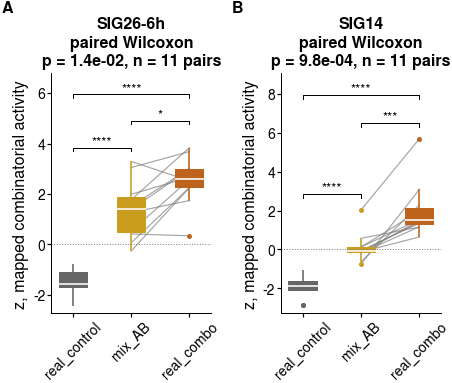

    dataset        group1      group2  statistic       p_value
0  SIG26-6h  real_control      mix_AB  -2.848086  8.835560e-08
1  SIG26-6h  real_control  real_combo  -4.014590  4.965195e-11
2  SIG26-6h        mix_AB  real_combo  -1.166505  1.335163e-02
3     SIG14  real_control      mix_AB  -1.990694  1.122791e-04
4     SIG14  real_control  real_combo  -3.894012  5.282466e-10
5     SIG14        mix_AB  real_combo  -1.903317  2.027794e-04


In [4]:
import pandas as pd
from scipy.stats import tukey_hsd

tukey_results = []

panels = cns.multipanel(max_width=620)
for dataset in DATASETS:
    subset = long.query("dataset == @dataset and sample_type in @SAMPLE_TYPES")
    ax = panels.panel(width=80, height=120)
    cns.boxplot(data=subset, x="sample_type", y="z_AB",
                order=SAMPLE_TYPES, showoutliers=True, ax=ax, pairs="all",
                hue = "sample_type", palette = ["#E6AB02FF", "#D95F02FF", "#666666FF"])

    w = paired["z_AB"].loc[dataset]

    # paired lines linking each ligand pair's mixture to its matched real combination
    xm, xc = SAMPLE_TYPES.index("mix_AB"), SAMPLE_TYPES.index("real_combo")
    for _, row in w.iterrows():
        ax.plot([xm, xc], [row["mix_AB"], row["real_combo"]],
                color="grey", lw=0.6, alpha=0.7, zorder=1)

    # Tukey HSD across sample_type groups (scipy gives exact p-values, not
    # statsmodels' psturng-truncated ones which floor/ceiling at 0.001/0.9)
    groups = [subset.loc[subset["sample_type"] == s, "z_AB"].values for s in SAMPLE_TYPES]
    tukey = tukey_hsd(*groups)
    n = len(SAMPLE_TYPES)
    for i in range(n):
        for j in range(i + 1, n):
            tukey_results.append({
                "dataset": dataset,
                "group1": SAMPLE_TYPES[i],
                "group2": SAMPLE_TYPES[j],
                "statistic": tukey.statistic[i, j],
                "p_value": tukey.pvalue[i, j],
            })

    row = summary.query("dataset == @dataset").iloc[0]
    ax.axhline(0, color="grey", lw=0.5, ls=":")
    ax.set(xlabel="", ylabel="z, mapped combinatorial activity",
           title=f"{dataset}\npaired Wilcoxon\np = {row.wilcoxon_p:.1e}, n = {row.n_ligand_pairs} pairs")
    ax.tick_params(axis="x", rotation=45)
savefig("01_combinatorial_activity_by_sample_type")

tukey_all = pd.DataFrame(tukey_results)
print(tukey_all)

## 3. Combinatorial vs. single activity effect sizes

Section 2 tested whether the combinatorial activity is higher in the real combination than in
the mixture. A stronger test: is it the *dominant* signal, larger than either single activity?

The readout is the **margin**, `d_AB - max(d_A, d_B)`, using control-subtracted scores.
A positive margin means the combinatorial activity beats the stronger single activity.
Expected result: margin at or below zero for mixtures, above zero for real combinations.

In [5]:
effect_summary = (long.query("sample_type in @STIMULATED")
                      .groupby(["dataset", "sample_type"])
                      .agg(median_d_AB=("d_AB", "median"),
                           median_d_best_single=("d_best_single", "median"),
                           median_margin=("margin", "median"),
                           margin_positive=("margin", lambda s: f"{(s > 0).sum()}/{len(s)}"))
                      .reset_index())
effect_summary.to_csv(f"{OUTDIR}/combinatorial_vs_single_effect_size.csv", index=False)
print(effect_summary.to_string(index=False))

print()
for dataset in DATASETS:
    m = paired["margin"].loc[dataset]
    print(f"{dataset}: margin real_combo vs mix_AB, paired Wilcoxon p = "
          f"{stats.wilcoxon(m['real_combo'], m['mix_AB']).pvalue:.4f}, "
          f"median shift = {np.median(m['real_combo'] - m['mix_AB']):.2f}")

 dataset sample_type  median_d_AB  median_d_best_single  median_margin margin_positive
   SIG14      mix_AB     1.802643              2.948621      -1.117091            1/11
   SIG14  real_combo     3.316033              2.782941       0.654404            9/11
SIG26-6h      mix_AB     2.947807              2.789883       0.032273            6/11
SIG26-6h  real_combo     4.078906              3.309207       0.635044            7/11

SIG26-6h: margin real_combo vs mix_AB, paired Wilcoxon p = 0.0830, median shift = 0.29
SIG14: margin real_combo vs mix_AB, paired Wilcoxon p = 0.0010, median shift = 1.60


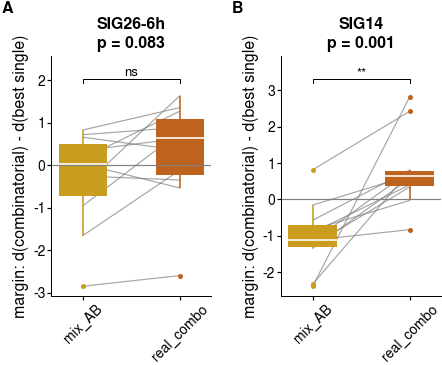

In [6]:
effects = (long.query("sample_type in @STIMULATED")
               .melt(id_vars=["dataset", "triplet", "sample_type"],
                     value_vars=["d_A", "d_B", "d_AB"],
                     var_name="activity_role", value_name="effect")
               .replace({"activity_role": {"d_A": "single A", "d_B": "single B",
                                           "d_AB": "combinatorial"}})
               .dropna(subset=["effect"]))

panels = cns.multipanel(max_width=620)
for dataset in DATASETS:
    ax = panels.panel(width=80, height=120)
    m = paired["margin"].loc[dataset]
    cns.boxplot(data=long.query("dataset == @dataset and sample_type in @STIMULATED"),
                x="sample_type", y="margin", order=STIMULATED, showoutliers=True,
                pairs="all", ax=ax,
                hue = "sample_type", palette = ["#E6AB02FF", "#D95F02FF"])
    for _, row in m.iterrows():
        ax.plot([0, 1], [row["mix_AB"], row["real_combo"]],
                color="grey", lw=0.6, alpha=0.7, zorder=1)
    ax.axhline(0, color="grey", lw=0.6)
    ax.set(xlabel="", ylabel="margin: d(combinatorial) - d(best single)",
           title=f"{dataset}\np = {stats.wilcoxon(m['real_combo'], m['mix_AB']).pvalue:.3f}")
    ax.tick_params(axis="x", rotation=45)
savefig("02_combinatorial_vs_single_effect_size")

## 4. Per-pair breakdown

Pooled results can hide individual pairs the model misses. This shows the separation for each
ligand pair: delta z = `z_AB`(real combination) - `z_AB`(mixture). Bars show mean +/- SE
across replicates, and points show individual replicates.

In [7]:
rows = []
rep_rows = []
for dataset in DATASETS:
    scores = pd.read_csv(f"{INDIR}/activity_mixtures_{dataset}.csv")
    index = pd.read_csv(f"{INDIR}/sample_index_{dataset}.csv")
    delta = paired["z_AB"].loc[dataset]["real_combo"] - paired["z_AB"].loc[dataset]["mix_AB"]
    for triplet in index["triplet"].unique():
        rows.append(dict(dataset=dataset, triplet=triplet, delta_z=delta.loc[triplet]))

    # replicate-level delta_z, matched by replicate within each ligand pair -- shown alongside
    # the pair-level mean as std + points in the barplot below
    activities = [c for c in scores.columns if c != "sample"]
    merged = index.merge(scores, left_on="sample_id", right_on="sample", how="left")
    column_of = {activity: i for i, activity in enumerate(activities)}
    target_column = merged["activity_AB"].map(column_of).astype(int).to_numpy()
    merged["z_AB"] = merged[activities].to_numpy()[np.arange(len(merged)), target_column]
    wide = merged.pivot_table(index=["triplet", "replicate"], columns="sample_type", values="z_AB")
    rep_rows.append(wide.assign(dataset=dataset, delta_z=wide["real_combo"] - wide["mix_AB"])
                        .reset_index()[["dataset", "triplet", "replicate", "delta_z"]])
per_pair = pd.DataFrame(rows)
per_pair.to_csv(f"{OUTDIR}/per_ligand_pair_separation.csv", index=False)
per_pair_replicates = pd.concat(rep_rows, ignore_index=True).dropna(subset=["delta_z"])

In [8]:
per_pair

,dataset,triplet,delta_z
0,SIG26-6h,IL2+TNF,1.491740
1,SIG26-6h,IL4+TNF,2.187157
2,SIG26-6h,IL6+TNF,2.513712
3,SIG26-6h,IL21+TNF,2.053763
4,SIG26-6h,IL27+TNF,0.632720
5,SIG26-6h,IFNG+TNF,2.058684
6,SIG26-6h,TGFB+TNF,0.475927
7,SIG26-6h,IL4+IL21,0.669495
8,SIG26-6h,IL27+IL21,-0.766055
9,SIG26-6h,TGFB+IL4,1.588233


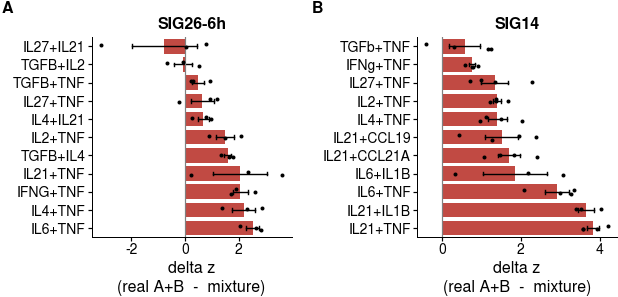

ligand pairs with no separation:
dataset   triplet  
SIG26-6h  IL27+IL21   -0.77
          TGFB+IL2    -0.07


In [9]:
panels = cns.multipanel(max_width=620)
for dataset in DATASETS:
    ordered = per_pair.query("dataset == @dataset").sort_values("delta_z")
    order = list(ordered.triplet)
    reps = per_pair_replicates.query("dataset == @dataset")
    ax = panels.panel(width=100, height=100)
    cns.barplot(data=reps, y="triplet", x="delta_z", order=order,
                orient="h", errorbar="se", ax=ax)
    cns.stripplot(data=reps, y="triplet", x="delta_z", order=order, orient="h",
                  size=2, color="black", jitter=0.15, showmedian=False, ax=ax)
    ax.axvline(0, color="grey", lw=0.6)
    ax.set(xlabel="delta z\n(real A+B  -  mixture)", ylabel="", title=dataset)
savefig("03_per_pair_delta")

failing = per_pair.set_index(["dataset", "triplet"]).delta_z.pipe(lambda s: s[s <= 0])
print("ligand pairs with no separation:")
print(failing.round(2).to_string() if len(failing) else "  none")